In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [ ]:
path="BankChurners.csv"
churn=pd.read_csv(path)

In [ ]:
churn.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
churn.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377


In [ ]:
initial_drop_cols=['CLIENTNUM','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

In [ ]:
data=churn.drop(initial_drop_cols,axis=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [ ]:
data.shape

(10127, 20)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data_cleaned=data.drop_duplicates()

In [ ]:
data_cleaned.isnull().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


In [ ]:
#encoding categoricval values

In [ ]:
cols_to_convert=data_cleaned.select_dtypes(include='object').columns.to_list()
data_cleaned[cols_to_convert]=data_cleaned[cols_to_convert].astype('category')

In [ ]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Attrition_Flag            10127 non-null  category
 1   Customer_Age              10127 non-null  int64   
 2   Gender                    10127 non-null  category
 3   Dependent_count           10127 non-null  int64   
 4   Education_Level           10127 non-null  category
 5   Marital_Status            10127 non-null  category
 6   Income_Category           10127 non-null  category
 7   Card_Category             10127 non-null  category
 8   Months_on_book            10127 non-null  int64   
 9   Total_Relationship_Count  10127 non-null  int64   
 10  Months_Inactive_12_mon    10127 non-null  int64   
 11  Contacts_Count_12_mon     10127 non-null  int64   
 12  Credit_Limit              10127 non-null  float64 
 13  Total_Revolving_Bal       10127 non-null  int6

In [ ]:
cols_to_encode=data_cleaned.select_dtypes(include='category').columns.to_list()
cols_to_encode.remove('Attrition_Flag')
data_cleaned_encode=pd.get_dummies(data_cleaned,columns=cols_to_encode,dtype=int)


In [ ]:
data_cleaned_add_original=pd.concat([data_cleaned_encode,data_cleaned[cols_to_encode]],axis=1)

In [ ]:
data_cleaned_add_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Attrition_Flag                  10127 non-null  category
 1   Customer_Age                    10127 non-null  int64   
 2   Dependent_count                 10127 non-null  int64   
 3   Months_on_book                  10127 non-null  int64   
 4   Total_Relationship_Count        10127 non-null  int64   
 5   Months_Inactive_12_mon          10127 non-null  int64   
 6   Contacts_Count_12_mon           10127 non-null  int64   
 7   Credit_Limit                    10127 non-null  float64 
 8   Total_Revolving_Bal             10127 non-null  int64   
 9   Avg_Open_To_Buy                 10127 non-null  float64 
 10  Total_Amt_Chng_Q4_Q1            10127 non-null  float64 
 11  Total_Trans_Amt                 10127 non-null  int64   
 12  Total_Trans_Ct    

In [ ]:
## split into train test split

In [ ]:
data_cleaned_add_original['Attrition_Flag'].value_counts()


,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


In [ ]:
data_cleaned_add_original['target']=data_cleaned_add_original['Attrition_Flag'].apply(lambda x: 1 if x=='Attrited Customer'  else 0)

In [ ]:
X=data_cleaned_add_original.drop(['Attrition_Flag','target'],axis=1)
y=data_cleaned_add_original[['target']]

In [ ]:
y['target']=y['target'].astype(int)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=25,test_size=0.2)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8101, 42)
(2026, 42)
(8101, 1)
(2026, 1)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8101 entries, 7501 to 8510
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Customer_Age                    8101 non-null   int64   
 1   Dependent_count                 8101 non-null   int64   
 2   Months_on_book                  8101 non-null   int64   
 3   Total_Relationship_Count        8101 non-null   int64   
 4   Months_Inactive_12_mon          8101 non-null   int64   
 5   Contacts_Count_12_mon           8101 non-null   int64   
 6   Credit_Limit                    8101 non-null   float64 
 7   Total_Revolving_Bal             8101 non-null   int64   
 8   Avg_Open_To_Buy                 8101 non-null   float64 
 9   Total_Amt_Chng_Q4_Q1            8101 non-null   float64 
 10  Total_Trans_Amt                 8101 non-null   int64   
 11  Total_Trans_Ct                  8101 non-null   int64   
 12  Total_Ct_Chng_Q4_Q1   

In [ ]:
## Exploratory data analysis

In [ ]:
train=pd.concat([X_train,y_train],axis=1)

Overall churn rate is 16.32%


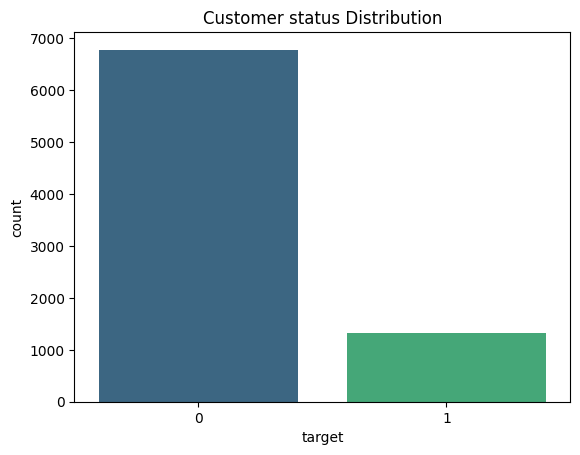

In [ ]:
churn_rate=train['target'].mean()*100
print(f"Overall churn rate is {churn_rate:.2f}%")
sns.countplot(x='target',data=train,palette="viridis")
plt.title('Customer status Distribution')
plt.show()

In [ ]:
## Univariate analysis

In [ ]:
cols_category=train.select_dtypes(include='category').columns.to_list()
cols_category

['Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

categorical feature analysis


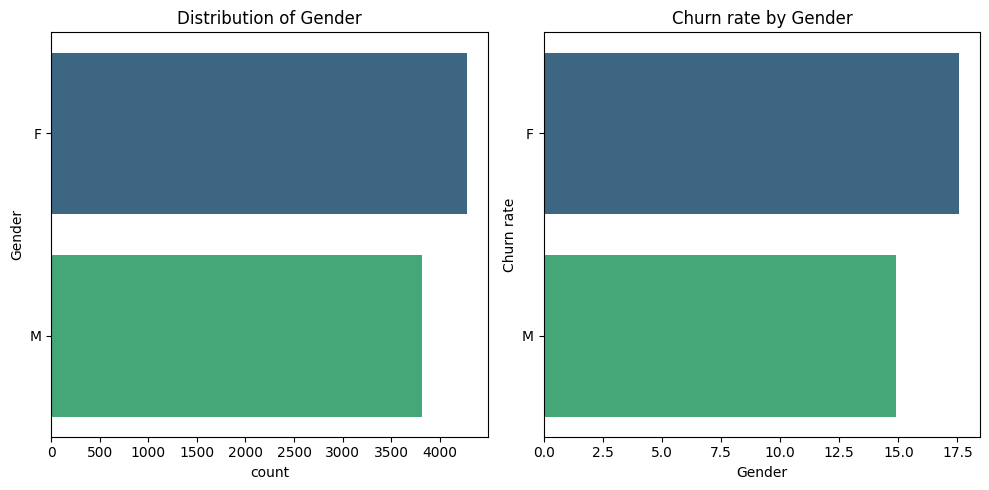


Value counts for  Gender:
Gender
F    4279
M    3822
Name: count, dtype: int64

Churn rate by Gender:
Gender
F    17.574200
M    14.913658
Name: target, dtype: float64


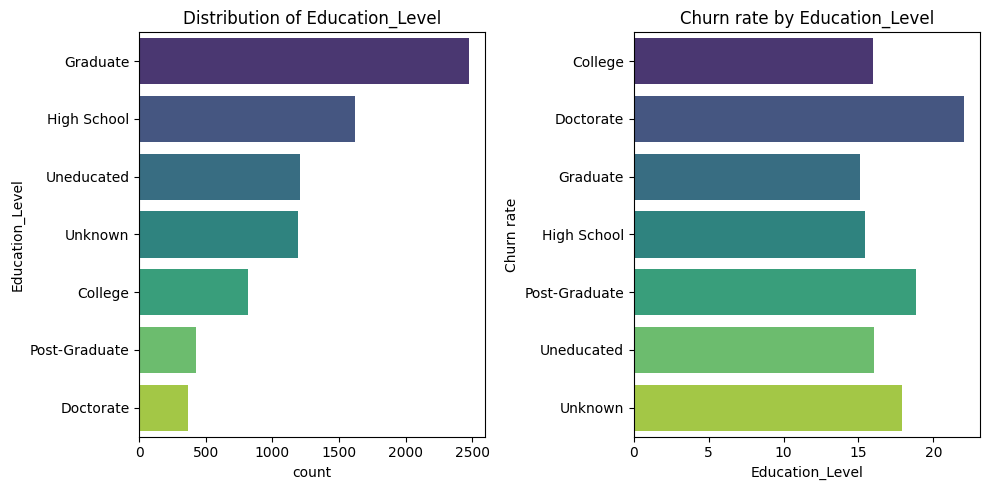


Value counts for  Education_Level:
Education_Level
Graduate         2473
High School      1620
Uneducated       1205
Unknown          1195
College           815
Post-Graduate     425
Doctorate         368
Name: count, dtype: int64

Churn rate by Education_Level:
Education_Level
Doctorate        22.010870
Post-Graduate    18.823529
Unknown          17.907950
Uneducated       16.016598
College          15.950920
High School      15.432099
Graduate         15.123332
Name: target, dtype: float64


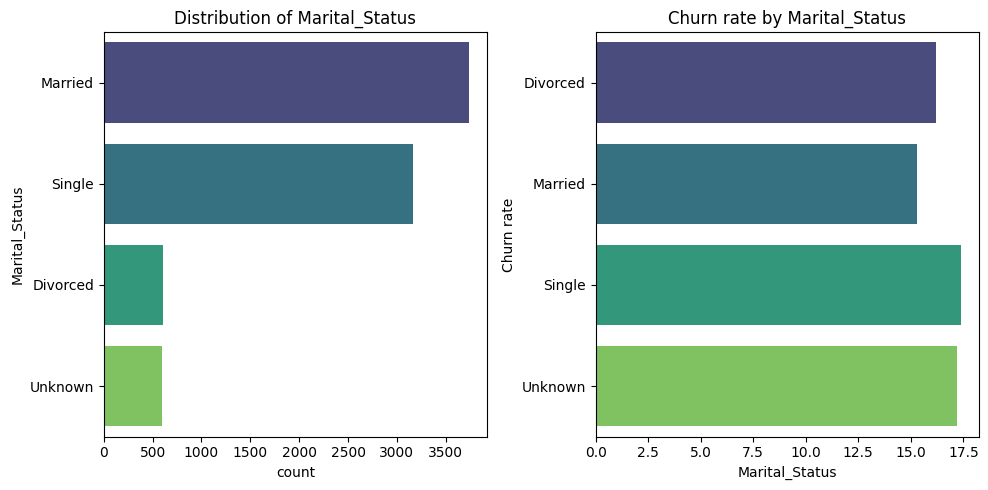


Value counts for  Marital_Status:
Marital_Status
Married     3736
Single      3161
Divorced     611
Unknown      593
Name: count, dtype: int64

Churn rate by Marital_Status:
Marital_Status
Single      17.367922
Unknown     17.200675
Divorced    16.202946
Married     15.310493
Name: target, dtype: float64


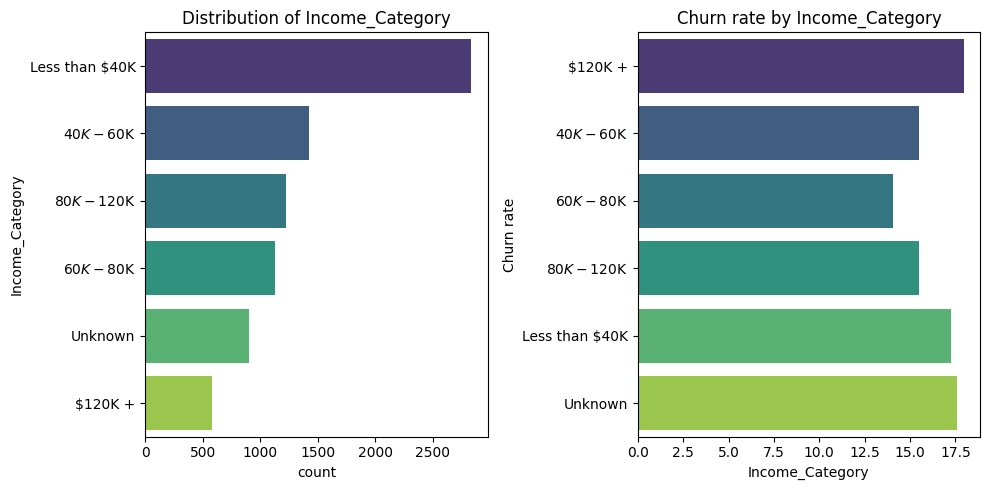


Value counts for  Income_Category:
Income_Category
Less than $40K    2836
$40K - $60K       1424
$80K - $120K      1227
$60K - $80K       1132
Unknown            903
$120K +            579
Name: count, dtype: int64

Churn rate by Income_Category:
Income_Category
$120K +           17.962003
Unknown           17.607973
Less than $40K    17.242595
$40K - $60K       15.519663
$80K - $120K      15.484923
$60K - $80K       14.045936
Name: target, dtype: float64


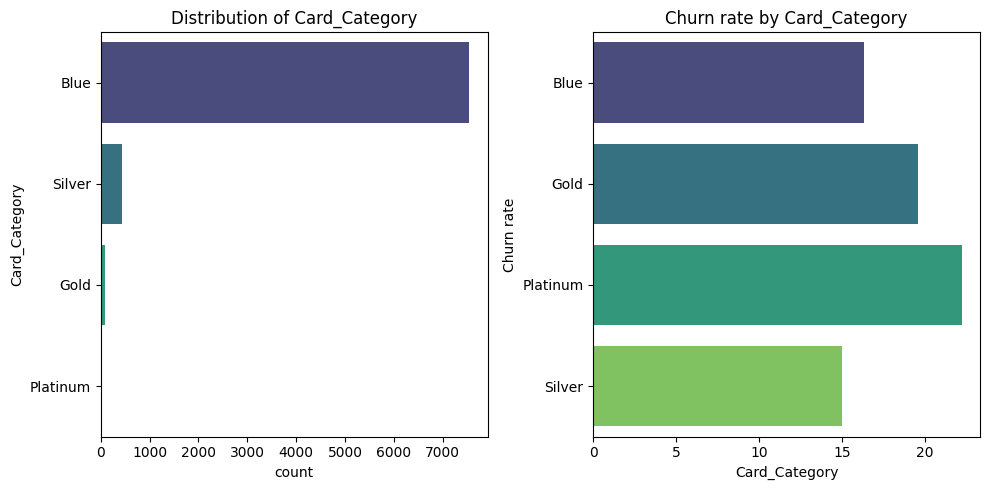


Value counts for  Card_Category:
Card_Category
Blue        7540
Silver       446
Gold          97
Platinum      18
Name: count, dtype: int64

Churn rate by Card_Category:
Card_Category
Platinum    22.222222
Gold        19.587629
Blue        16.339523
Silver      15.022422
Name: target, dtype: float64


In [ ]:
print("categorical feature analysis")

for col in cols_category:

  plt.figure(figsize=(10,5))

  #plot 1:distribution of category
  plt.subplot(1,2,1)
  sns.countplot(y=col,data=train,order=train[col].value_counts().index,palette="viridis")
  plt.title(f"Distribution of {col}")
  plt.ylabel(col)
  plt.xlabel("count")

  #plot 2:Churn rate by category
  plt.subplot(1,2,2)
  churn_rate=train.groupby(col)['target'].mean().sort_values(ascending=False)*100

  sns.barplot(x=churn_rate.values,y=churn_rate.index,palette="viridis")
  plt.title(f"Churn rate by {col}")
  plt.ylabel("Churn rate")
  plt.xlabel(col)

  plt.tight_layout()
  plt.show()

  print(f"\nValue counts for  {col}:")
  print(train[col].value_counts())
  print(f"\nChurn rate by {col}:")
  print(churn_rate)

In [ ]:
## univariate analysis for numerical features

In [ ]:
data_cleaned.select_dtypes(exclude='category').columns.to_list()

['Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

In [ ]:
numerical_cols=data_cleaned.select_dtypes(exclude='category').columns.to_list()

In [ ]:
print("numerical feature summary")
train[numerical_cols].describe().T

numerical feature summary


,count,mean,std,min,25%,50%,75%,max
Customer_Age,8101.0,46.325515,7.993227,26.0,41.000,46.000,52.000,73.000
Dependent_count,8101.0,2.349216,1.303607,0.0,1.000,2.000,3.000,5.000
Months_on_book,8101.0,35.901247,7.966946,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,8101.0,3.807431,1.555698,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,8101.0,2.346007,1.008063,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,8101.0,2.450685,1.112641,0.0,2.000,2.000,3.000,6.000
Credit_Limit,8101.0,8654.909579,9128.997141,1438.3,2564.000,4533.000,11115.000,34516.000
Total_Revolving_Bal,8101.0,1154.957660,816.610723,0.0,193.000,1272.000,1775.000,2517.000
Avg_Open_To_Buy,8101.0,7499.951920,9132.443273,10.0,1345.000,3471.000,9930.000,34516.000
Total_Amt_Chng_Q4_Q1,8101.0,0.760079,0.217848,0.0,0.631,0.736,0.858,3.397


numerical feature analysis


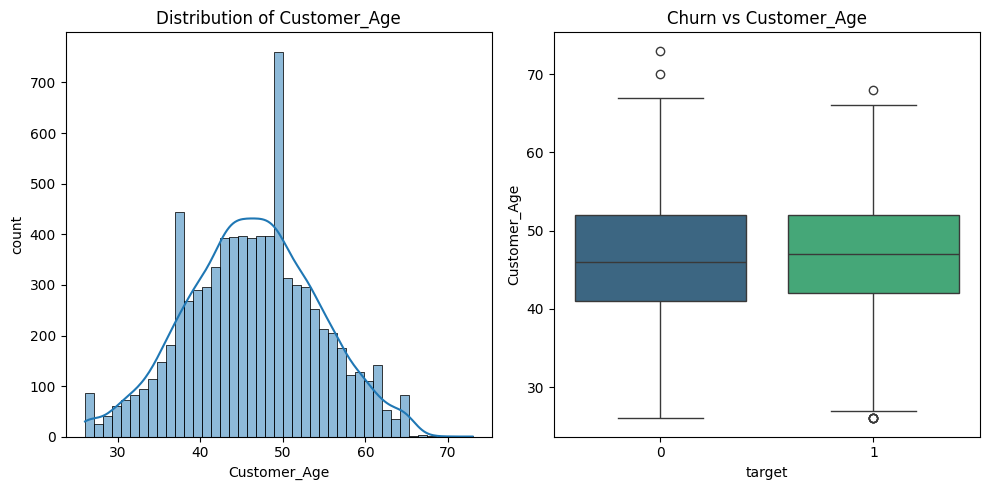

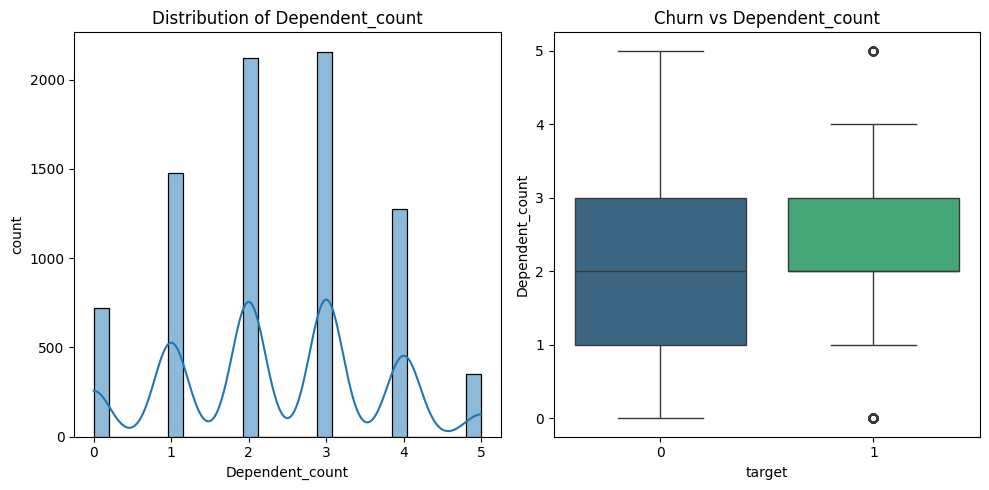

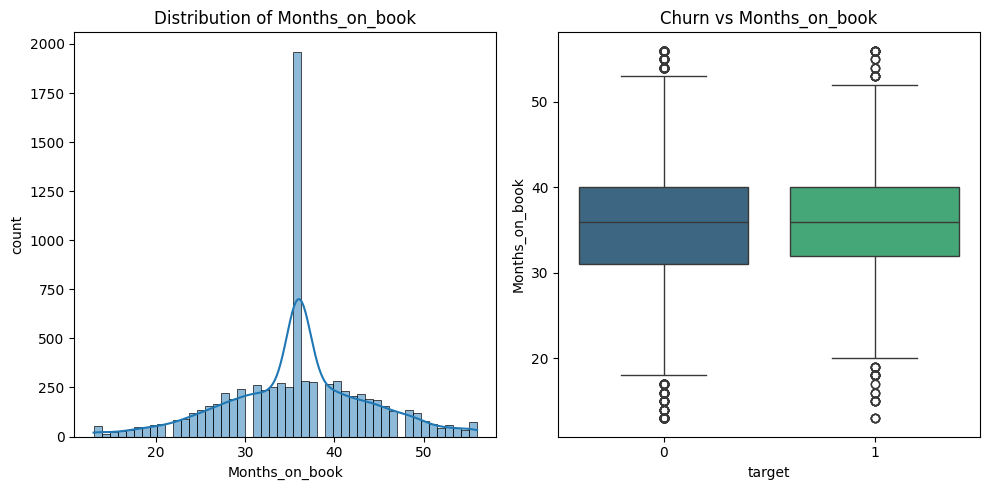

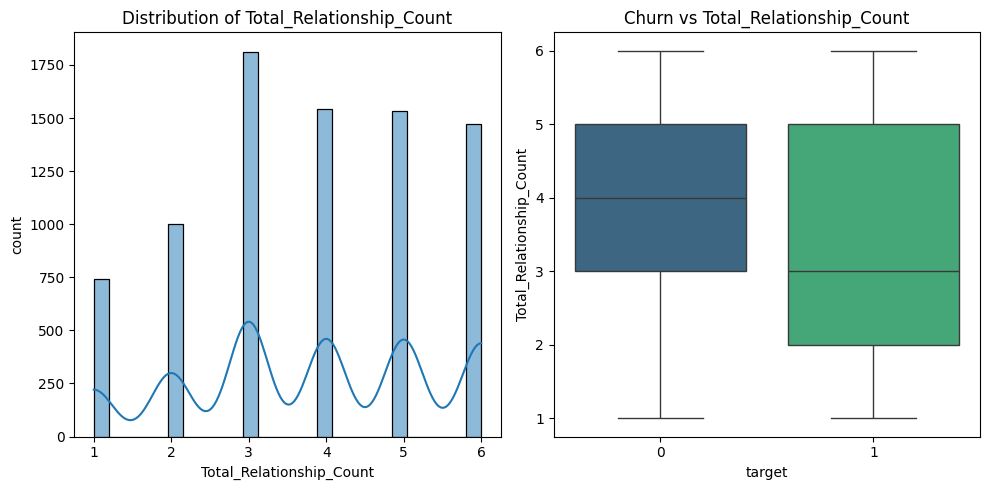

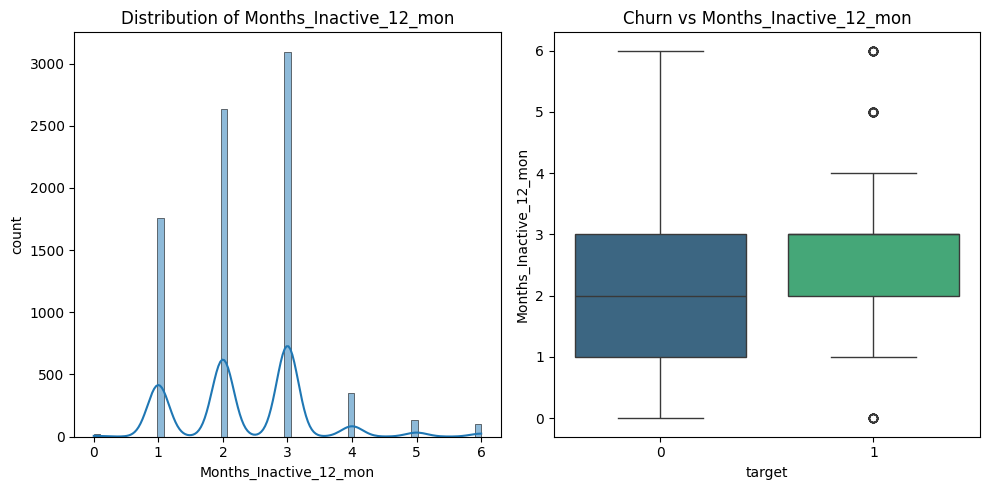

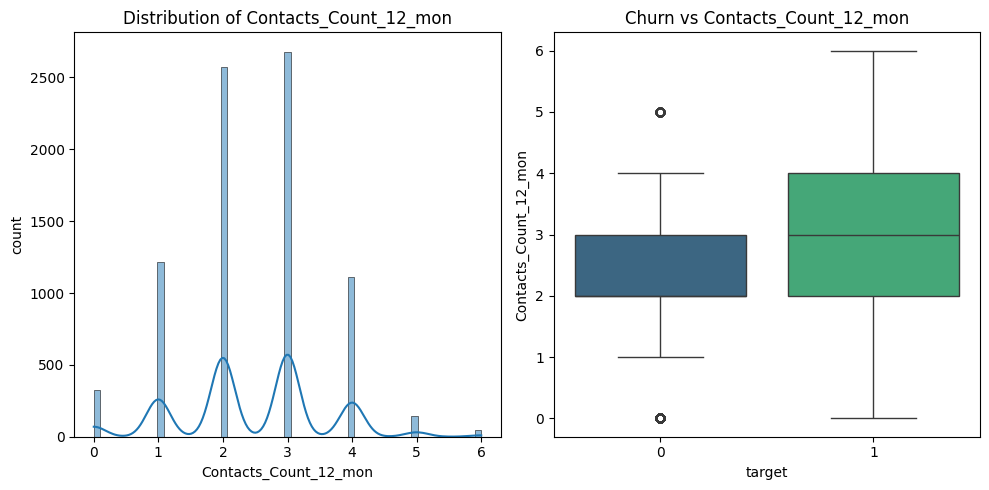

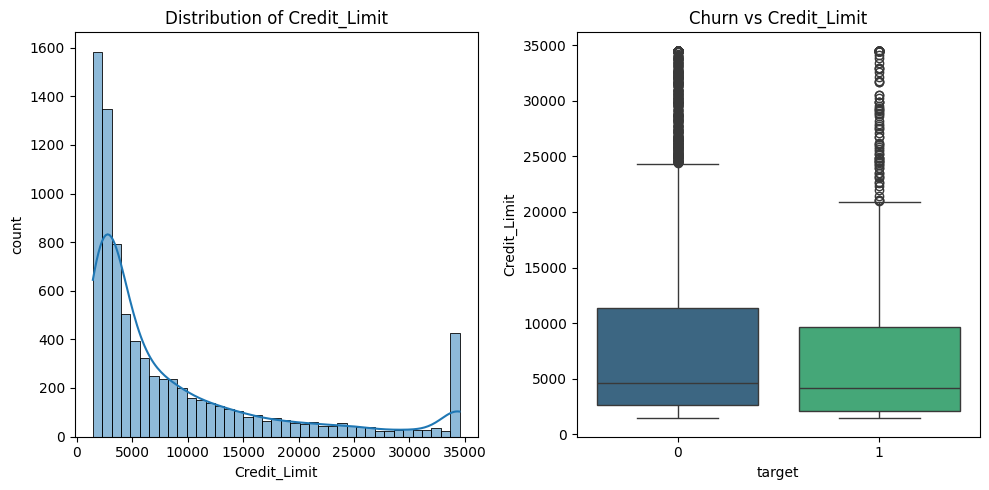

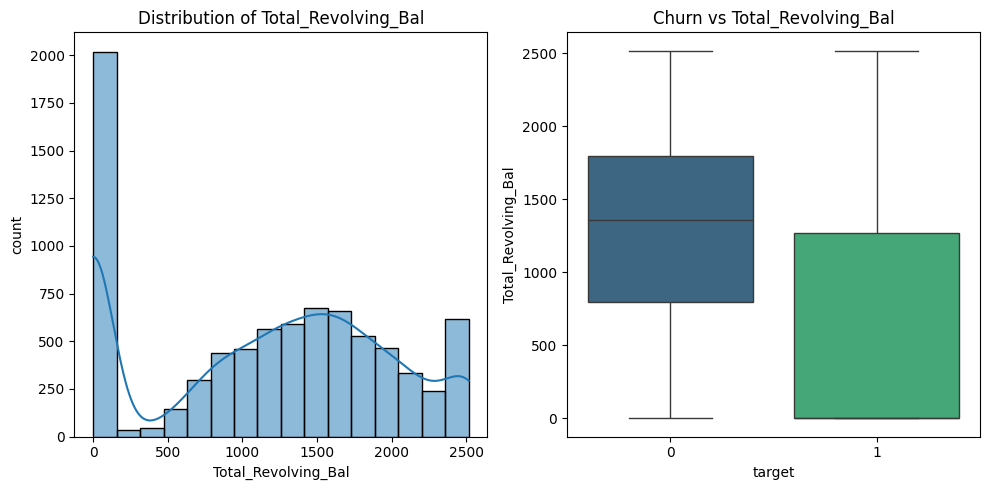

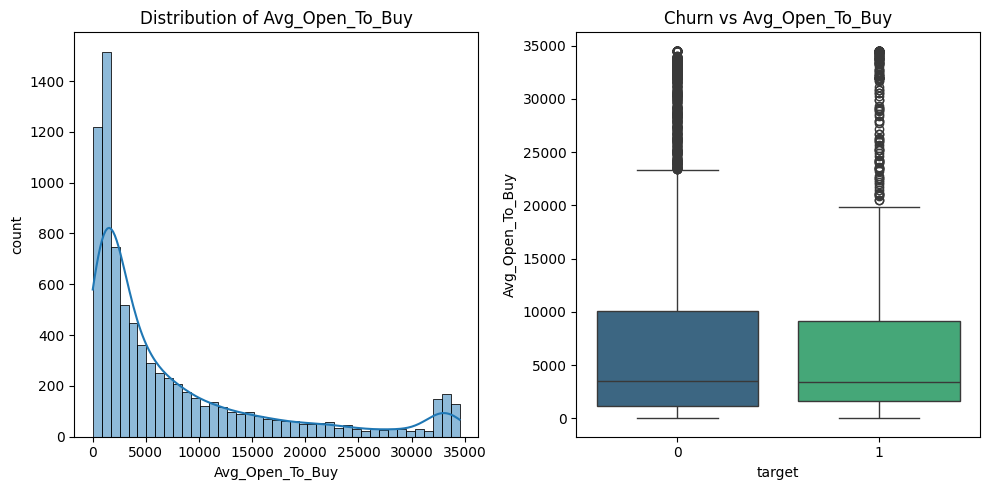

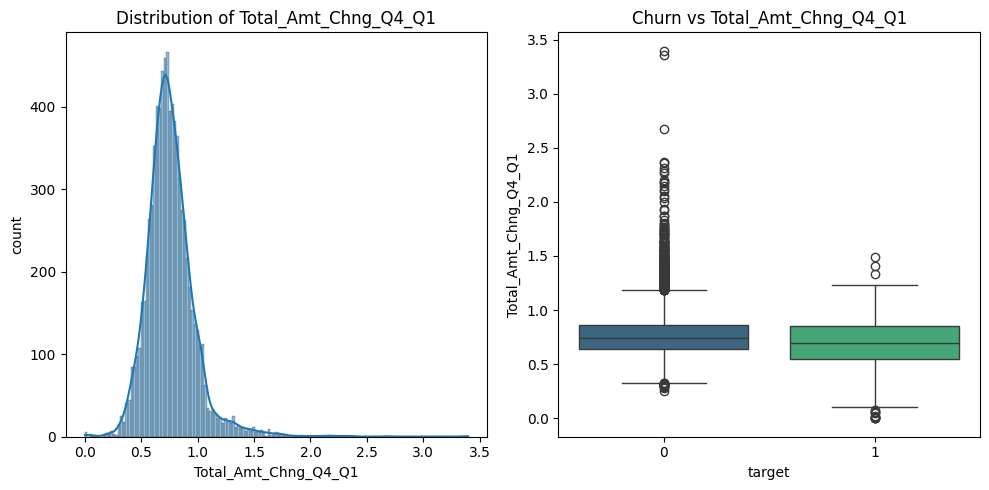

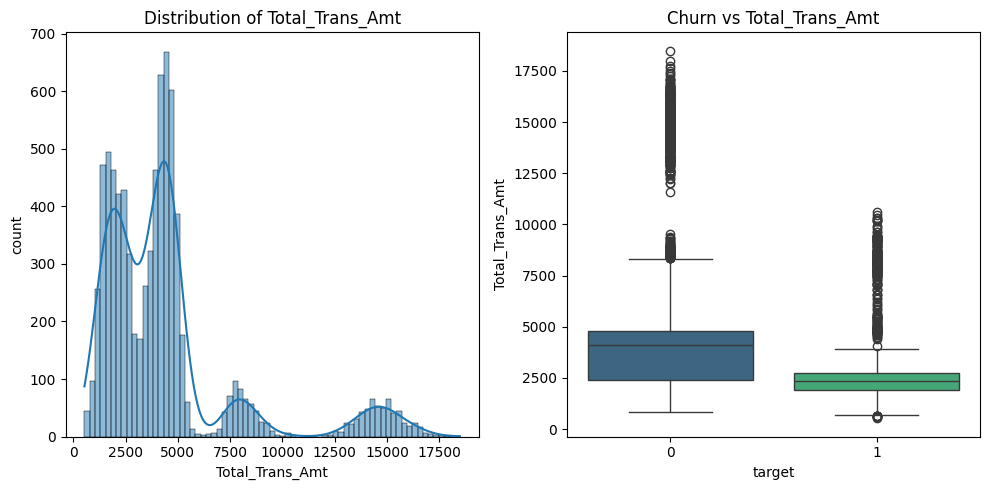

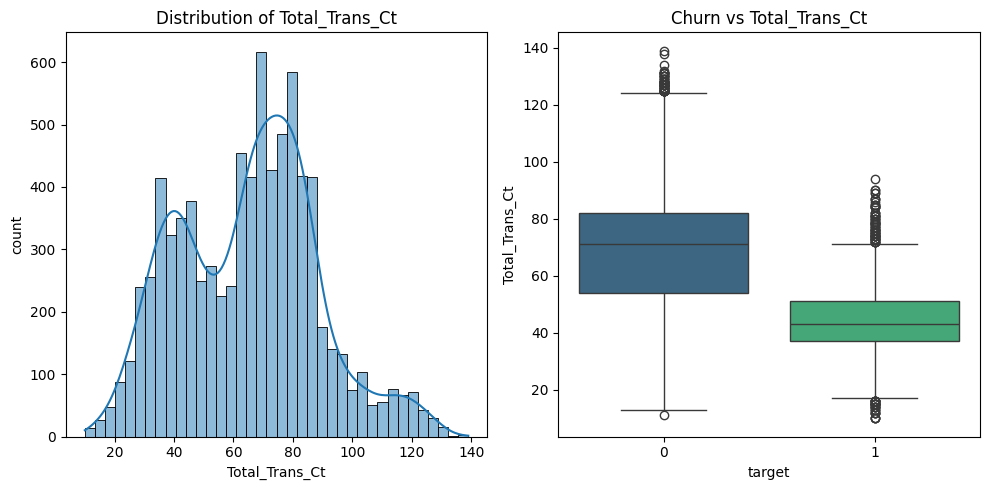

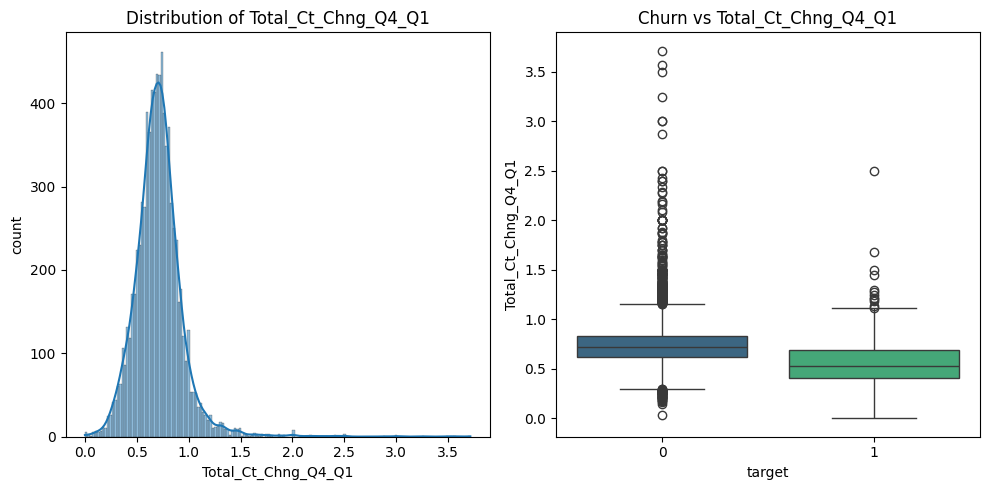

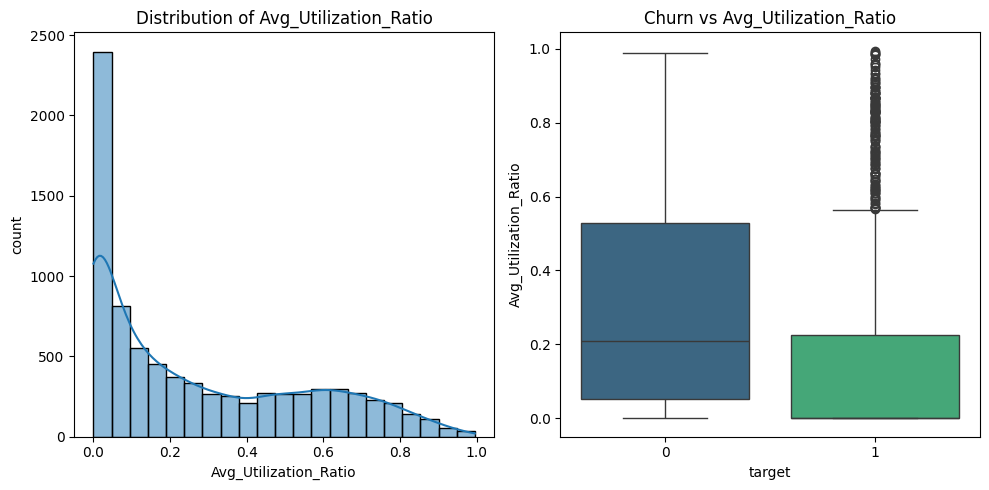

In [ ]:
print("numerical feature analysis")

for col in numerical_cols:

  plt.figure(figsize=(10,5))

  #plot 1:distribution of numerical columns
  plt.subplot(1,2,1)
  sns.histplot(data=train,x=col,kde=True,palette="viridis")
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("count")


  #plot 2:boxplot comparing churn and no churn
  plt.subplot(1,2,2)
  sns.boxplot(x='target',y=col,data=train,palette="viridis")
  plt.title(f"Churn vs {col}")
  plt.xlabel("target")
  plt.ylabel(col)

  plt.tight_layout()
  plt.show()

In [ ]:
#Multivariate analysis

In [ ]:
numericals_cols_with_target=numerical_cols + ['target']
corr_matrix=train[numericals_cols_with_target].corr()

In [ ]:
corr_matrix

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,target
Customer_Age,1.000000,-0.121571,0.790009,-0.004172,0.055397,-0.009474,0.001010,0.004536,0.000604,-0.072879,-0.046583,-0.070926,-0.015195,0.000446,0.029785
Dependent_count,-0.121571,1.000000,-0.099800,-0.038791,-0.010038,-0.037620,0.066080,-0.001794,0.066215,-0.037910,0.024698,0.048535,0.011633,-0.037531,0.019306
Months_on_book,0.790009,-0.099800,1.000000,-0.004752,0.077165,0.004478,0.006953,-0.000792,0.007021,-0.059073,-0.035173,-0.049784,-0.013376,-0.014254,0.023463
Total_Relationship_Count,-0.004172,-0.038791,-0.004752,1.000000,-0.002301,0.054496,-0.067942,0.017760,-0.069505,0.050495,-0.347753,-0.239973,0.050193,0.070375,-0.147614
Months_Inactive_12_mon,0.055397,-0.010038,0.077165,-0.002301,1.000000,0.031451,-0.017426,-0.042923,-0.013582,-0.026937,-0.038391,-0.044963,-0.041504,-0.016141,0.158597
Contacts_Count_12_mon,-0.009474,-0.037620,0.004478,0.054496,0.031451,1.000000,0.021169,-0.049539,0.025590,-0.024574,-0.113922,-0.152857,-0.098949,-0.057745,0.203023
Credit_Limit,0.001010,0.066080,0.006953,-0.067942,-0.017426,0.021169,1.000000,0.040505,0.996001,0.007817,0.168275,0.075867,-0.001176,-0.480486,-0.028212
Total_Revolving_Bal,0.004536,-0.001794,-0.000792,0.017760,-0.042923,-0.049539,0.040505,1.000000,-0.048929,0.059783,0.067835,0.060587,0.094340,0.629580,-0.263520
Avg_Open_To_Buy,0.000604,0.066215,0.007021,-0.069505,-0.013582,0.025590,0.996001,-0.048929,1.000000,0.002468,0.162146,0.070421,-0.009611,-0.536601,-0.004638
Total_Amt_Chng_Q4_Q1,-0.072879,-0.037910,-0.059073,0.050495,-0.026937,-0.024574,0.007817,0.059783,0.002468,1.000000,0.036868,0.000784,0.379407,0.039471,-0.128738


Text(0.5, 1.0, 'Correlation Matrix')

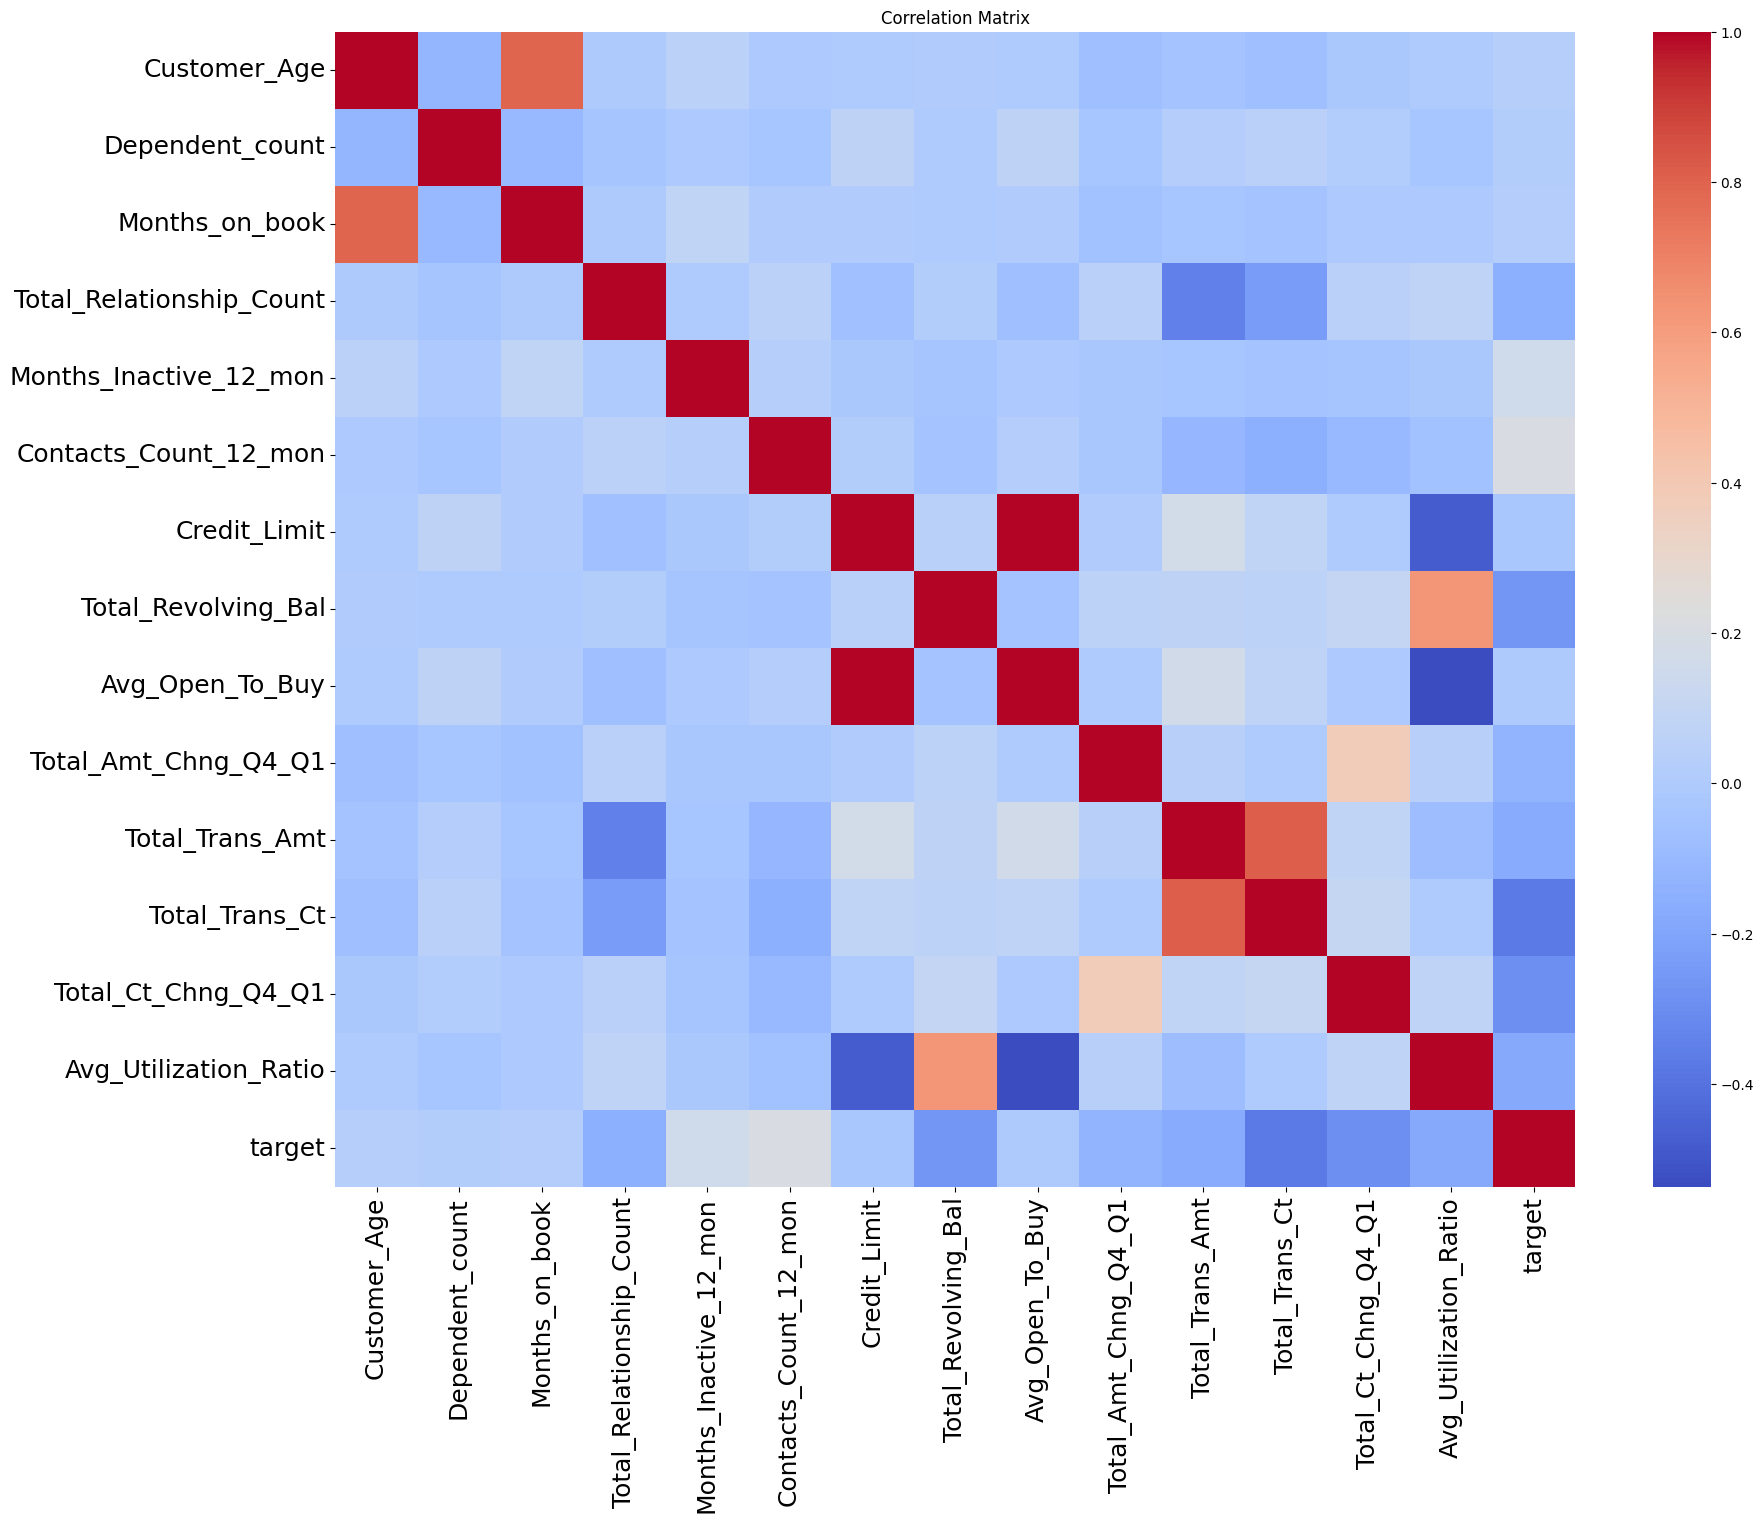

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix,cmap='coolwarm', fmt='.2f')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Correlation Matrix')

In [ ]:
print(corr_matrix['target'].sort_values(ascending=False))

target                      1.000000
Contacts_Count_12_mon       0.203023
Months_Inactive_12_mon      0.158597
Customer_Age                0.029785
Months_on_book              0.023463
Dependent_count             0.019306
Avg_Open_To_Buy            -0.004638
Credit_Limit               -0.028212
Total_Amt_Chng_Q4_Q1       -0.128738
Total_Relationship_Count   -0.147614
Total_Trans_Amt            -0.174211
Avg_Utilization_Ratio      -0.178281
Total_Revolving_Bal        -0.263520
Total_Ct_Chng_Q4_Q1        -0.292700
Total_Trans_Ct             -0.374386
Name: target, dtype: float64


In [ ]:
#Numerical-categorical bivariavte analysis on churn rates

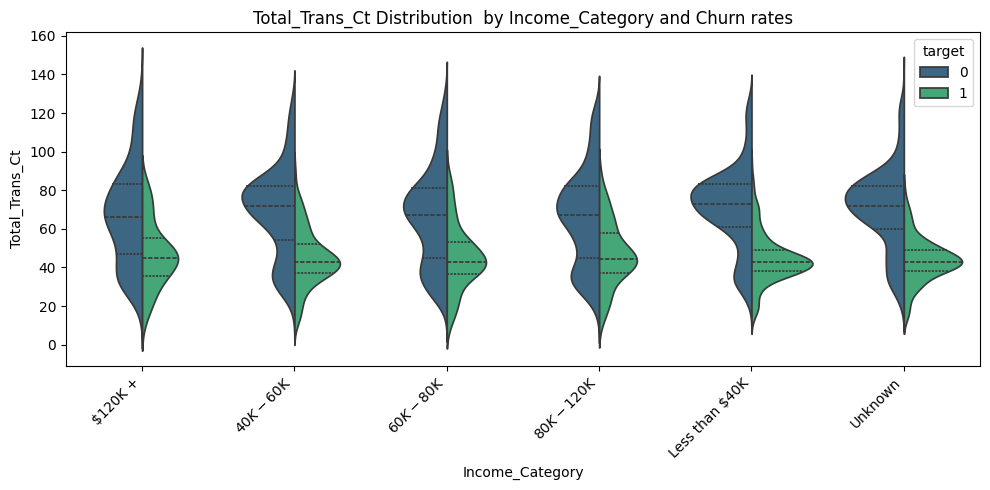

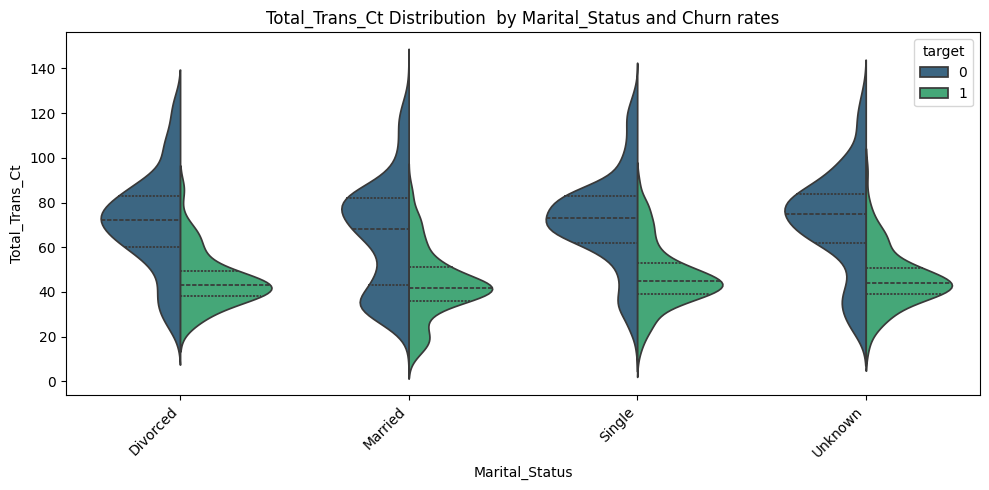

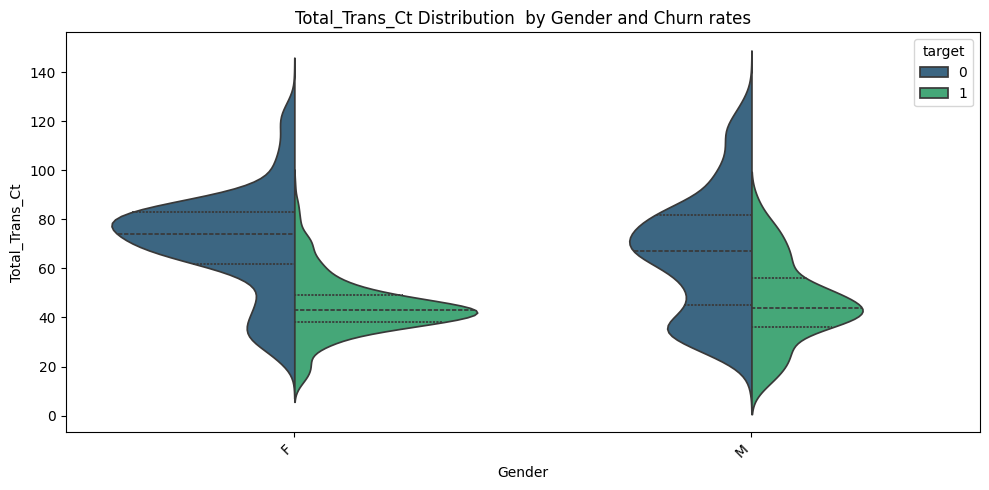

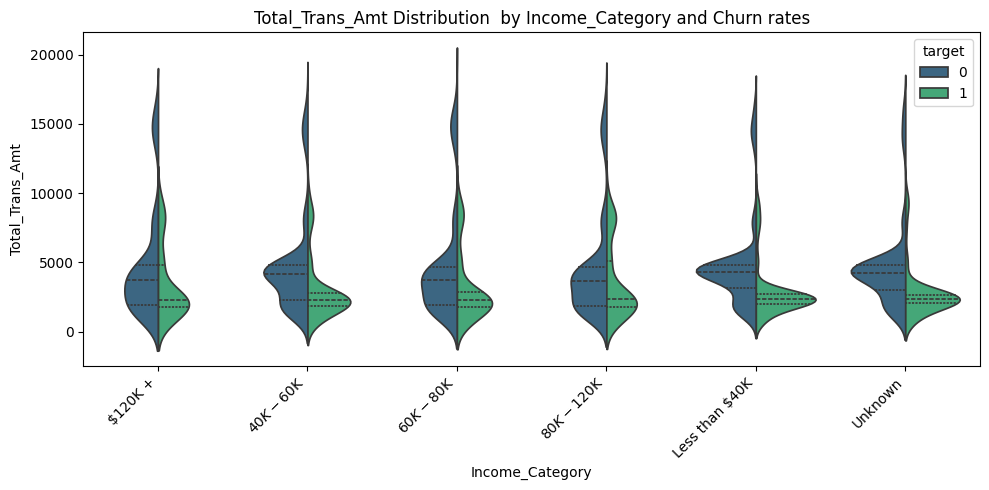

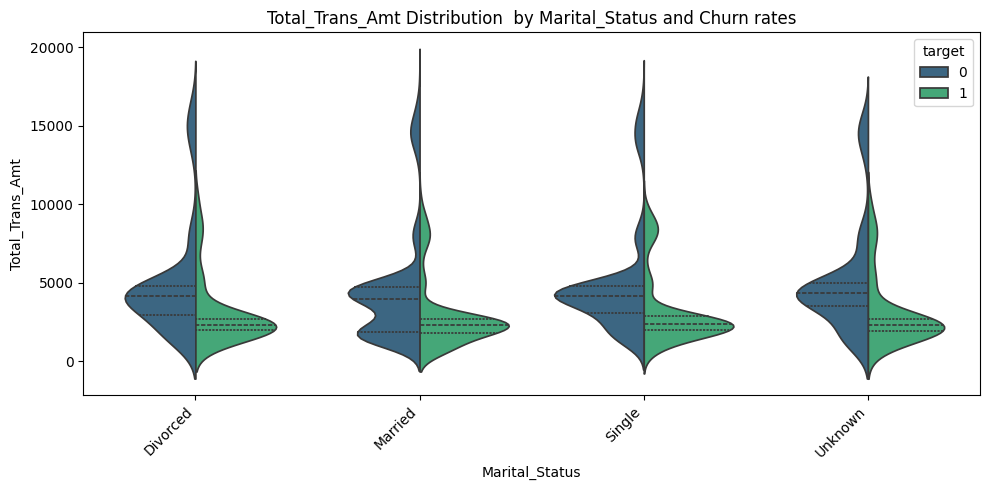

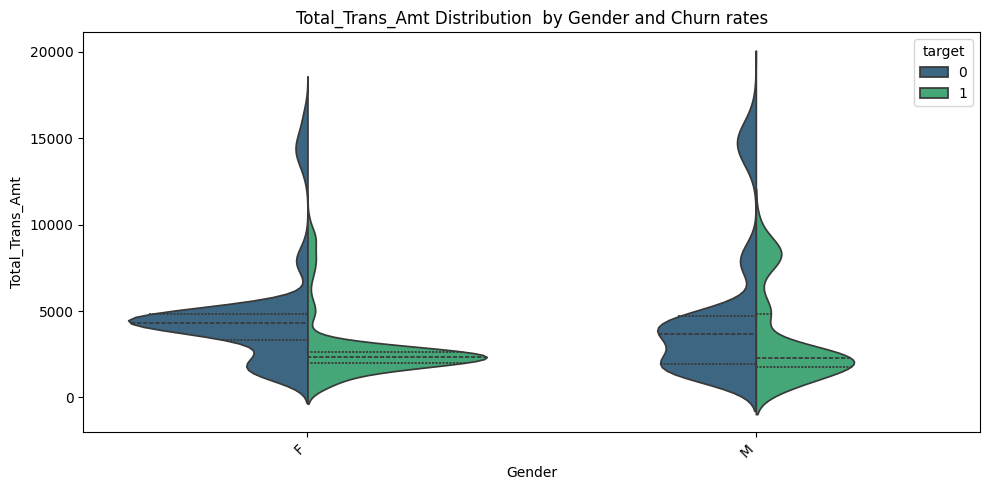

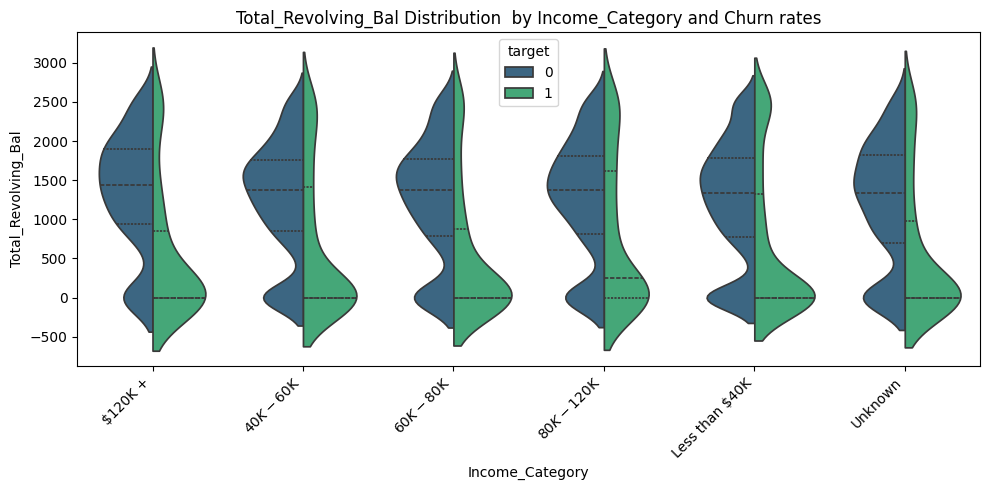

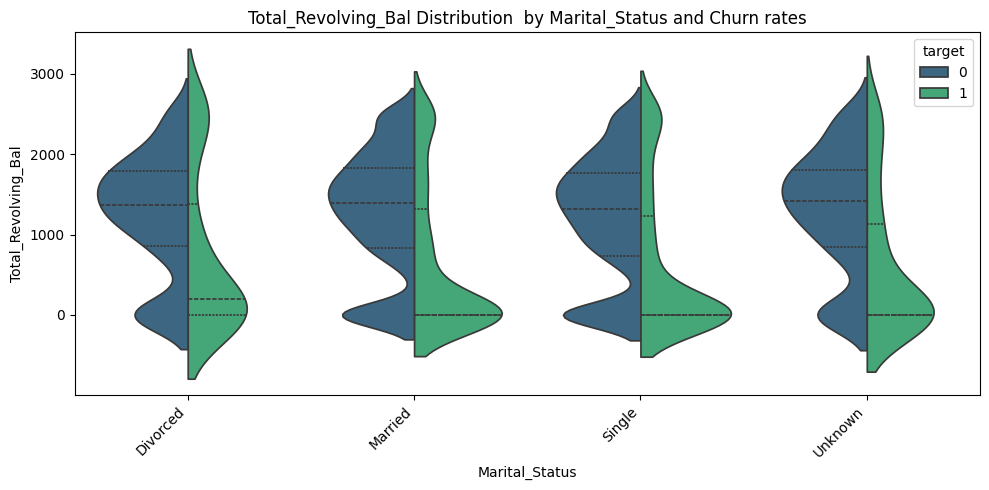

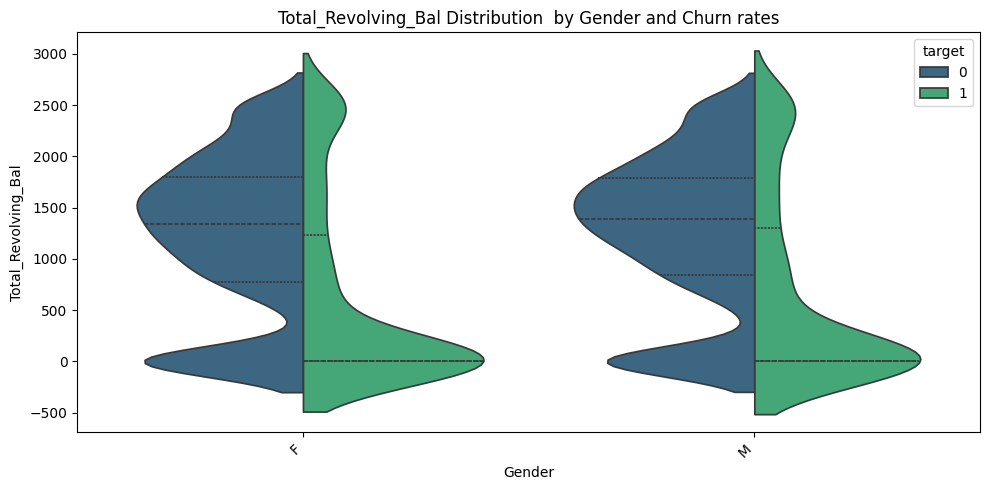

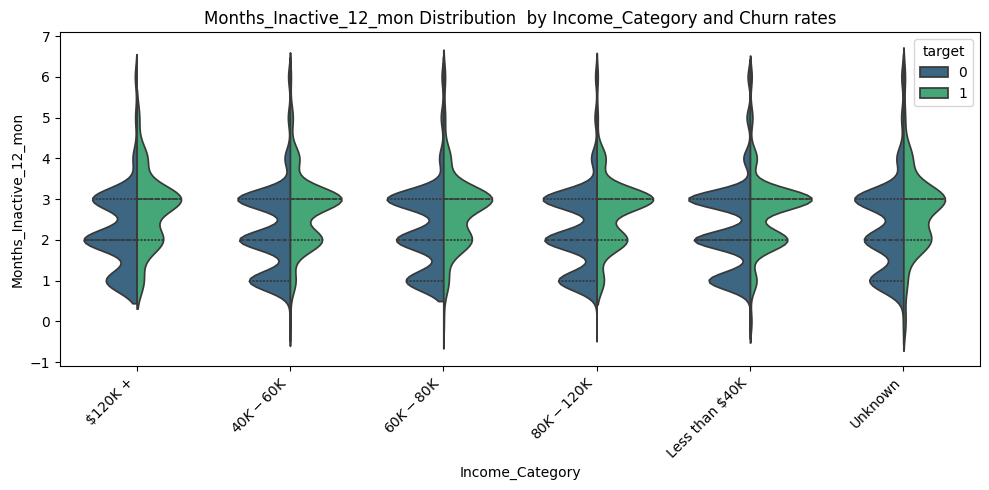

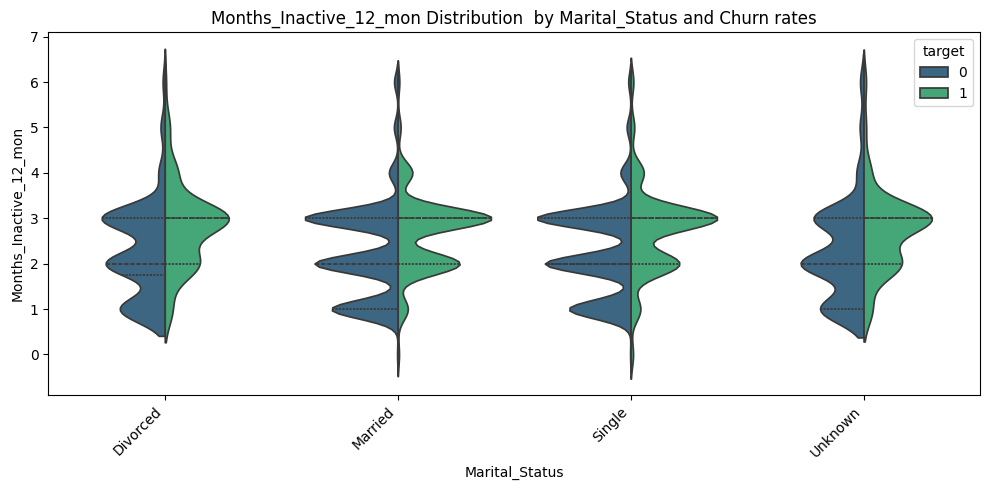

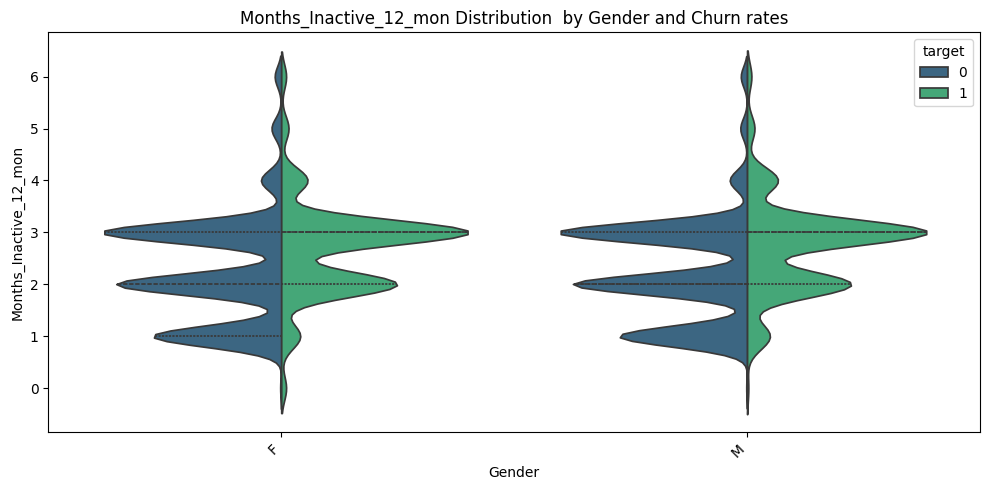

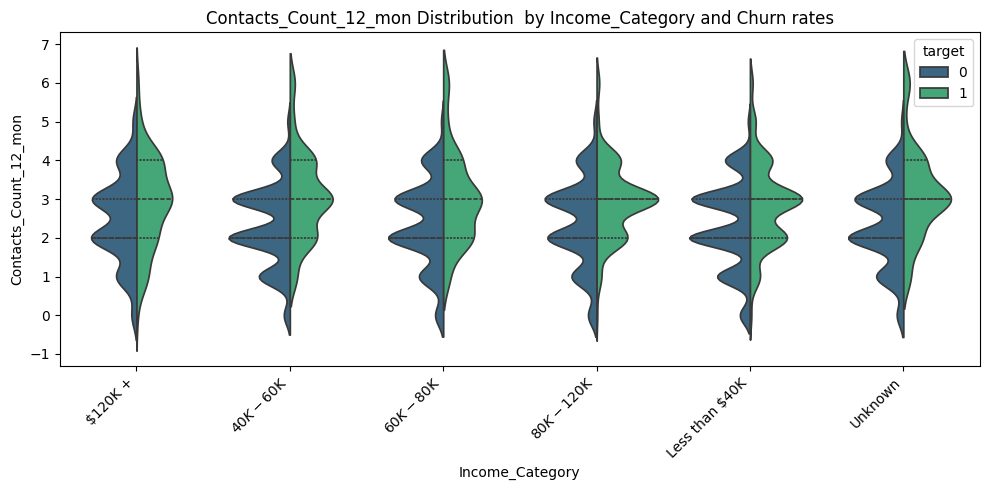

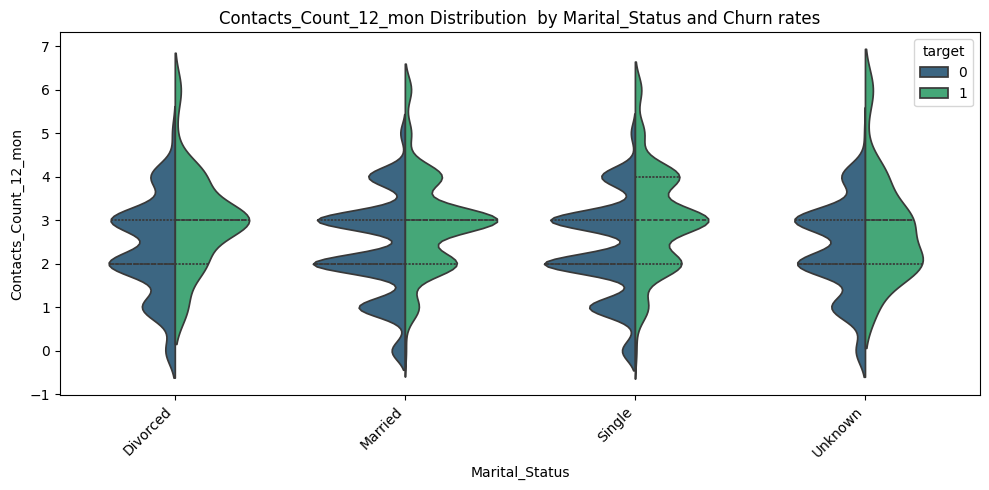

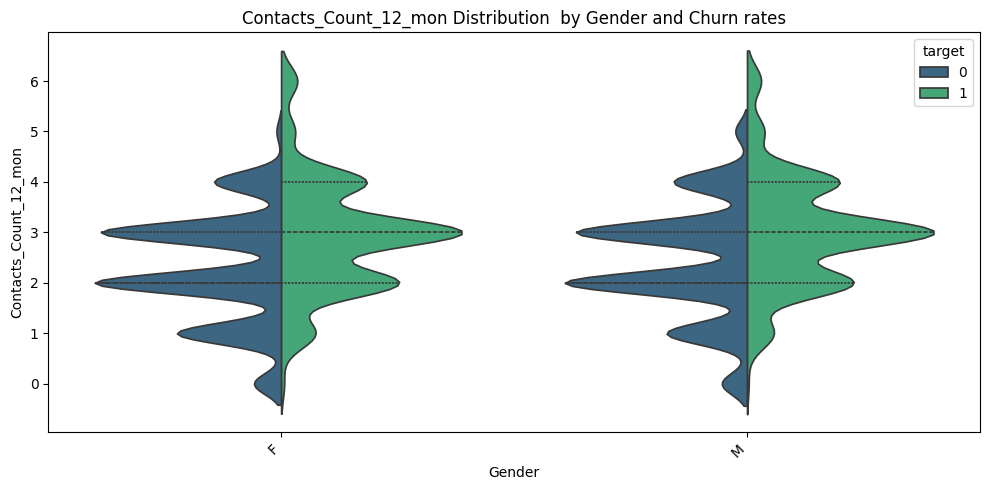

In [ ]:
key_numerical_cols=['Total_Trans_Ct','Total_Trans_Amt','Total_Revolving_Bal', 'Months_Inactive_12_mon','Contacts_Count_12_mon']
key_categorical_cols=['Income_Category','Marital_Status','Gender']

for num_col in key_numerical_cols:
  for cat_col in key_categorical_cols:
    plt.figure(figsize=(10,5))
    sns.violinplot(x=cat_col,y=num_col,data=train,hue='target',split=True,inner="quart",palette="viridis")
    plt.title(f'{num_col} Distribution  by {cat_col} and Churn rates')
    plt.xticks(rotation=45,ha='right')
    plt.tight_layout()
    plt.show()


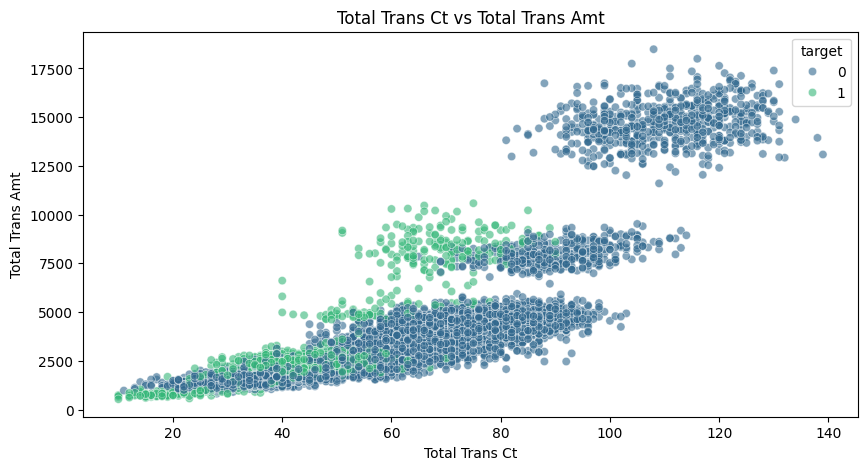

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=train,x='Total_Trans_Ct',y='Total_Trans_Amt',hue='target',alpha=0.6,palette='viridis')
plt.title('Total Trans Ct vs Total Trans Amt')
plt.xlabel('Total Trans Ct')
plt.ylabel('Total Trans Amt')
plt.show()

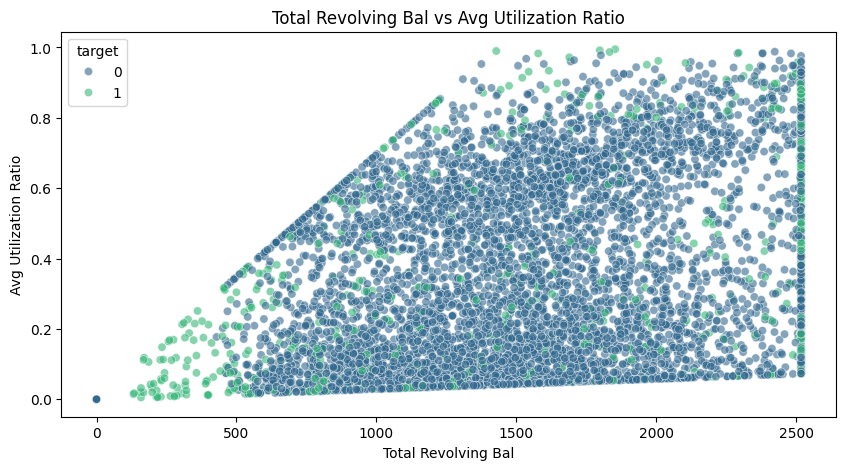

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=train,x='Total_Revolving_Bal',y='Avg_Utilization_Ratio',hue='target',alpha=0.6,palette='viridis')
plt.title('Total Revolving Bal vs Avg Utilization Ratio')
plt.xlabel('Total Revolving Bal')
plt.ylabel('Avg Utilization Ratio')
plt.show()